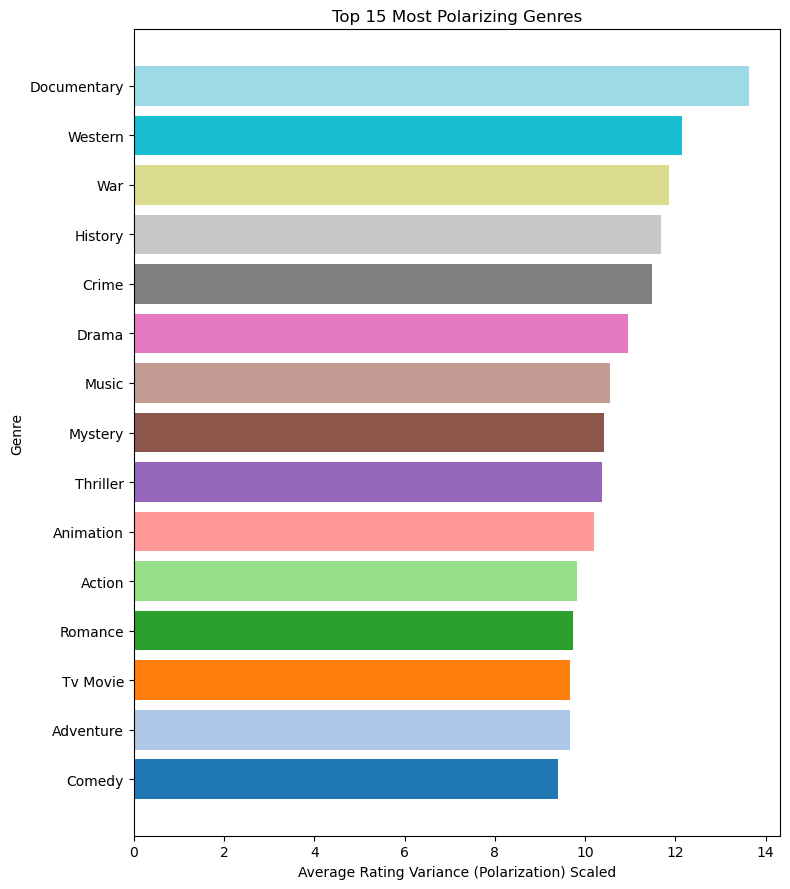

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

# Read data into notebook
df = pd.read_csv("Movie_Data_File.csv")

star_cols = [
    "½",
    "★",
    "★½",
    "★★",
    "★★½",
    "★★★",
    "★★★½",
    "★★★★",
    "★★★★½",
    "★★★★★"
]

# Remove rows without genre
df = df.dropna(subset=["Genres"])

# Genres are comma-separated so split and explode
df["Genres"] = df["Genres"].apply(ast.literal_eval)
df = df.explode("Genres")
# Need to clean genres formatting
df["Genres"] = (
    df["Genres"]
    .str.strip() # Remove leading/trailing spaces
    .str.title() # Standardize capitalization
)

# Calculate total ratings per film
df["Total_Ratings_Calc"] = df[star_cols].sum(axis=1)

# Convert star counts into proportions
for col in star_cols:
    df[col + "_prop"] = df[col] / df["Total_Ratings_Calc"]

prop_cols = [col + "_prop" for col in star_cols]

# Compute variance across rating proportions (polarization metric)
df["rating_variance"] = df[prop_cols].var(axis=1)

# Average polarization per genre
genre_polarization = (
    df.groupby("Genres")["rating_variance"]
    .mean()
    .sort_values(ascending=False)
)

# Show only top 15 most polarized genres for readability
top_n = 15
top_genres = genre_polarization.head(top_n)
top_genres_scaled = top_genres * 1000
sorted_genres = top_genres_scaled.sort_values()
colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_genres)))

plt.figure(figsize=(8, 9))
plt.barh(
    sorted_genres.index,
    sorted_genres.values,
    color=colors
)
plt.xlabel("Average Rating Variance (Polarization) Scaled")
plt.ylabel("Genre")
plt.title("Top 15 Most Polarizing Genres")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import altair as alt

df = pd.read_csv("Movie_Data_File.csv")

rating_cols = ['½','★','★½','★★','★★½','★★★','★★★½','★★★★','★★★★½','★★★★★']
df["Total_Ratings_Calc"] = df[rating_cols].sum(axis=1)

df["Average_Rating"] = df["Average_rating"]
df["Top_Genre"] = df["Genres"].str.split(",").str[0]
df["Language"] = df["Original_language"]

df["Reviews_Millions"] = df["Total_Ratings_Calc"] / 1_000_000

unique_movies = df.drop_duplicates(subset="Film_title")

top_movies = unique_movies.sort_values(
    "Total_Ratings_Calc",
    ascending=False
).head(150)

rating_median = top_movies["Average_Rating"].median()
review_median = top_movies["Reviews_Millions"].median()

def assign_quadrant(row):
    if row["Average_Rating"] >= rating_median and row["Reviews_Millions"] >= review_median:
        return "Acclaimed blockbusters"
    elif row["Average_Rating"] < rating_median and row["Reviews_Millions"] >= review_median:
        return "Commercial triumphs"
    elif row["Average_Rating"] >= rating_median and row["Reviews_Millions"] < review_median:
        return "Cult classics"
    else:
        return "Underperformers"

top_movies["Quadrant"] = top_movies.apply(assign_quadrant, axis=1)

colors = {
    "Acclaimed blockbusters": "green",
    "Commercial triumphs": "orange",
    "Cult classics": "blue",
    "Underperformers": "gray"
}

highlight = alt.selection_single(on="mouseover", empty="none")

chart = alt.Chart(top_movies).mark_circle(size=40).encode(
    
    x=alt.X(
        "Average_Rating:Q",
        title="Average Rating",
        scale=alt.Scale(domain=[2.5, 5]),
        axis=alt.Axis(tickCount=6, format=".1f")
    ),
    
    y=alt.Y(
        "Reviews_Millions:Q",
        title="Reviews (Millions)",
        axis=alt.Axis(format=".1f", tickCount=6)
    ),
    
    color=alt.Color(
        "Quadrant:N",
        scale=alt.Scale(domain=list(colors.keys()), range=list(colors.values()))
    ),
    
    size=alt.condition(highlight, alt.value(120), alt.value(40)),
    opacity=alt.condition(highlight, alt.value(1), alt.value(0.6)),
    
    tooltip=[
        "Film_title:N",
        "Top_Genre:N",
        "Language:N",
        alt.Tooltip("Average_Rating:Q", format=".2f"),
        alt.Tooltip("Reviews_Millions:Q", format=".2f")
    ]
).add_selection(highlight)

vline = alt.Chart(pd.DataFrame({"x": [rating_median]})).mark_rule(strokeDash=[5,5]).encode(x="x:Q")
hline = alt.Chart(pd.DataFrame({"y": [review_median]})).mark_rule(strokeDash=[5,5]).encode(y="y:Q")

(chart + vline + hline).properties(
    width=650,
    height=500
).interactive()

/var/folders/rk/nlx22y5961zcdvtk896_02400000gn/T/ipykernel_31969/2991161202.py:45: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  highlight = alt.selection_single(on="mouseover", empty="none")
/var/folders/rk/nlx22y5961zcdvtk896_02400000gn/T/ipykernel_31969/2991161202.py:77: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(highlight)


alt.LayerChart(...)

In [16]:
# remove duplicate films caused by exploding genres
unique_movies = df.drop_duplicates(subset="Film_title")

# filter movies with more than 500,000 reviews
filtered_movies = unique_movies[
    unique_movies["Total_Ratings_Calc"] > 500_000
]

# calculate average rating
avg_rating_500k = filtered_movies["Average_Rating"].mean()

print("Average Rating (Movies > 500k Reviews):",
      round(avg_rating_500k, 3))

print("Number of movies in this group:",
      len(filtered_movies))


Average Rating (Movies > 500k Reviews): 3.794
Number of movies in this group: 522


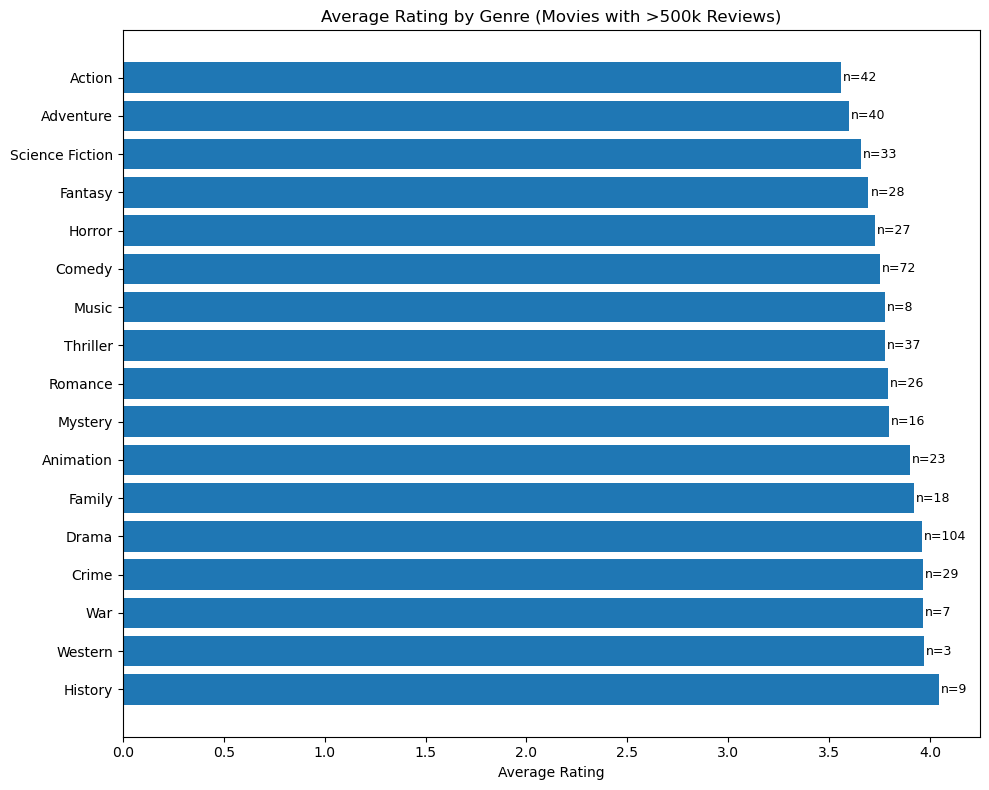

In [17]:
# remove duplicate films caused by exploding genres
unique_movies = df.drop_duplicates(subset="Film_title")

# keep only movies with more than 500k reviews
popular_movies = unique_movies[
    unique_movies["Total_Ratings_Calc"] > 500_000
]

# group by genre
genre_stats = (
    popular_movies
    .groupby("Genres")
    .agg(
        avg_rating=("Average_Rating", "mean"),
        movie_count=("Film_title", "count")
    )
    .sort_values("avg_rating", ascending=False)
)

# plotting visualization

plt.figure(figsize=(10, 8))

bars = plt.barh(
    genre_stats.index,
    genre_stats["avg_rating"]
)

plt.xlabel("Average Rating")
plt.title("Average Rating by Genre (Movies with >500k Reviews)")

# label bars with number of movies
for i, (rating, count) in enumerate(
        zip(genre_stats["avg_rating"],
            genre_stats["movie_count"])):
    
    plt.text(
        rating + 0.01,
        i,
        f"n={count}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()


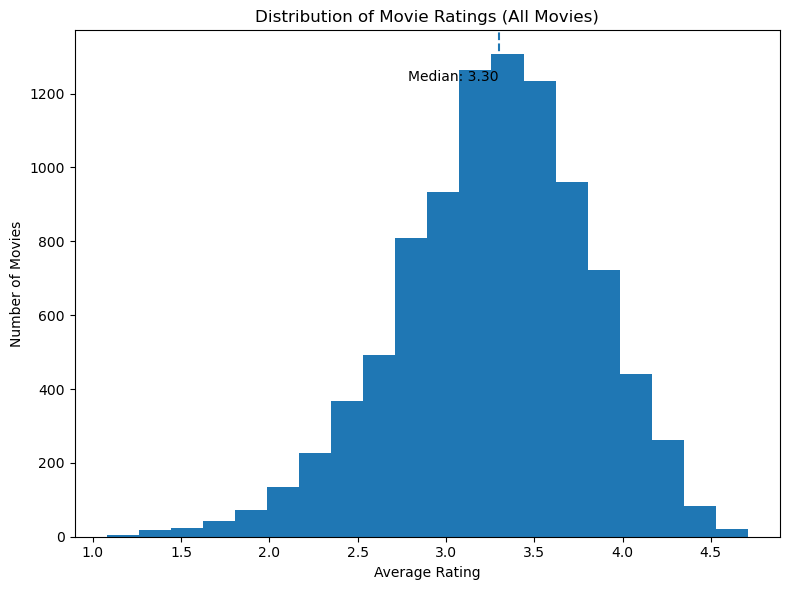

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# use full dataset instead of top_movies
ratings = df["Average_Rating"].dropna()

median_rating = ratings.median()

plt.figure(figsize=(8,6))

plt.hist(ratings, bins=20)

plt.axvline(median_rating, linestyle="--")

plt.text(
    median_rating,
    plt.ylim()[1]*0.9,
    f"Median: {median_rating:.2f}",
    ha="right"
)

plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Ratings (All Movies)")

plt.tight_layout()
plt.show()

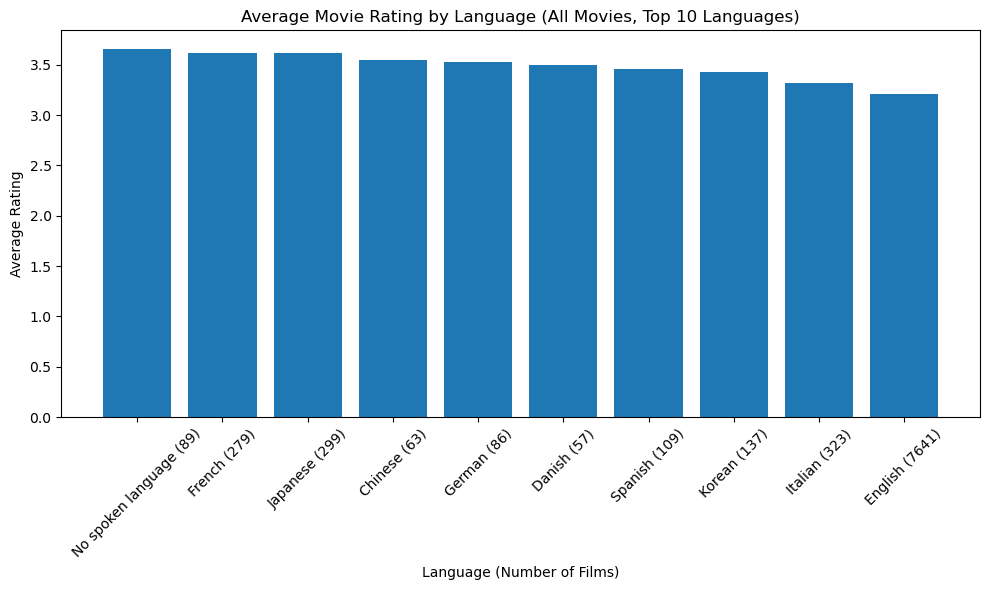

In [12]:
import matplotlib.pyplot as plt

# use full dataset
language_counts = df["Language"].value_counts()

# keep top 10 languages by number of films
top_languages = language_counts.head(10).index

filtered = df[df["Language"].isin(top_languages)]

language_stats = (
    filtered.groupby("Language")
    .agg(
        avg_rating=("Average_Rating", "mean"),
        film_count=("Average_Rating", "count")
    )
    .sort_values("avg_rating", ascending=False)
)

labels = [
    f"{lang} ({count})"
    for lang, count in zip(language_stats.index, language_stats["film_count"])
]

plt.figure(figsize=(10,6))

plt.bar(labels, language_stats["avg_rating"])

plt.xlabel("Language (Number of Films)")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating by Language (All Movies, Top 10 Languages)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()